## Settings & imports

In [1]:
import sys
sys.path.insert(1, '../src/')
from data_utils import *
from train_and_evaluate import *

In [2]:
import json

with open('../config.json', 'r') as f:
    config = json.load(f)


ELEMENTS_TO_KEEP_NO_FE = config["elements_to_keep_no_Fe"]
FIGURES_PATH = config["figures_path"]['all']

In [3]:
DATASETS = ['Konstytucja', 'corroded', 'Merkuriusz', 'Kopernik']

## Loading the data

In [4]:
dfs = []
labels = []

for DATASET in DATASETS:
    
    PREDICTION_PATH = config["prediction_path"][DATASET]
    PREPROCESSED_DATA_PATH = config["preprocessed_data_path"][DATASET]
    
    df = load_prediction(PREDICTION_PATH, ELEMENTS_TO_KEEP_NO_FE)
    y_true = load_target_data(PREPROCESSED_DATA_PATH, ['name'], header=0)['Sample_id']

    dfs.append(df)
    labels.append(DATASET + '_' + y_true)

df = pd.concat(dfs)
y_true = pd.concat(labels)
y_true = y_true.apply(lambda x: x.split('_')[0])

### Converting to np.array

In [5]:
X = np.array(df.values)

### Heatmap

### PCA - all points

In [6]:
from sklearn.decomposition import PCA

n_components = 4
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X)

In [7]:
pca.explained_variance_ratio_

array([0.54968641, 0.19488325, 0.08087446, 0.06785772])

In [8]:
pca.components_

array([[ 0.19684642,  0.18477575,  0.14811318,  0.40232935,  0.46236909,
         0.46126978,  0.54382386,  0.10974911,  0.09465069],
       [ 0.50380639,  0.00619016,  0.43175821, -0.02469197, -0.38617287,
         0.31700126, -0.26364575,  0.41679504, -0.25742859],
       [-0.10678401, -0.39179576,  0.10951037, -0.02935429,  0.62617373,
         0.07830684, -0.53322577,  0.32112812,  0.19120818],
       [-0.28144095, -0.28369248, -0.29151174, -0.15666151, -0.25968072,
         0.78979014, -0.03951798, -0.16670385,  0.10115958]])

In [9]:
ELEMENTS_TO_KEEP_NO_FE
# Most correlated
# Zn Cu Co > Mn / Al

['Al', 'S', 'Cr', 'Mn', 'Co', 'Cu', 'Zn', 'Pb', 'Mg']

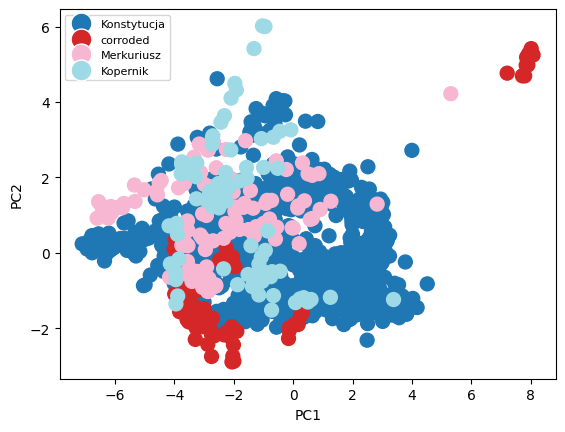

In [10]:
visualise_pca(X_pca, y_true, dimensions=[0,1], whether_sort=False, figures_path=FIGURES_PATH)

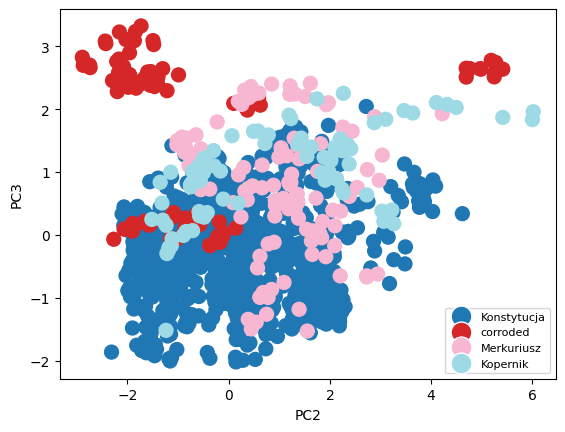

In [11]:
visualise_pca(X_pca, y_true, dimensions=[1, 2], whether_sort=False, figures_path=FIGURES_PATH)

### tSNE - all points

In [15]:
from sklearn.manifold import TSNE

n_components = 2
tsne = TSNE(n_components=n_components, random_state=42)
X_tsne = tsne.fit_transform(X)

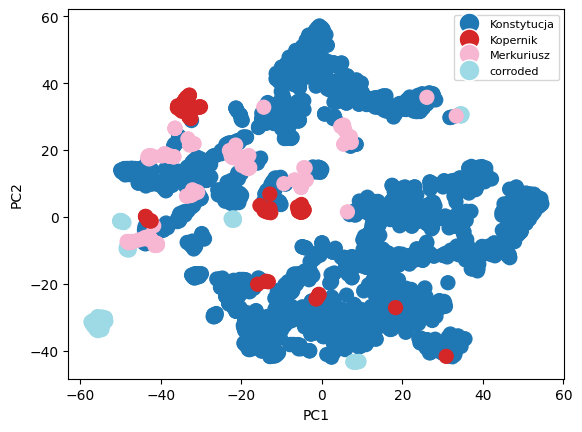

In [17]:
visualise_pca(X_tsne, y_true, dimensions=[0, 1], figures_path=FIGURES_PATH, figures_name='tsne')